In [ ]:
with open("/content/drive/MyDrive/Ciencia De Datos/charlaUlibro.txt", "r", encoding="utf-8") as archivo:
  discurso = archivo.read()

In [ ]:
print(discurso[:500])

...productor y escritor, reconocido por construir narrativas de gran fuerza visual y personajes intensos. En 2010 recibió el Premio Mundial Juvenal por salvar el juego. Entre sus obras también se encuentran Escuadrón Guillotina, El Museo de los Muertos, El Confuerzo de la Noche, El Salvaje, Extraños y El Hombre.

Mateo Gallino, el director de cine colombiano y el director creativo de la productora salsateriana Juan Lluís. Ha escrito y dirigido varios cortometrajes. En 2024 co-dirigió la serie do


In [ ]:
len(discurso)

14540

In [ ]:
discurso = discurso.lower()
discurso = discurso.replace(",", "")
discurso = discurso.replace(";", "")
discurso = discurso.replace(".", "")
discurso = discurso.replace(":", "")
discurso = discurso.replace("-", "")
discurso = discurso.replace("—", "")
discurso = discurso.replace("¿", "")
len(discurso)

13483

In [ ]:
palabras = discurso.split()
print(palabras[:20])

['productor', 'y', 'escritor', 'reconocido', 'por', 'construir', 'narrativas', 'de', 'gran', 'fuerza', 'visual', 'y', 'personajes', 'intensos', 'en', '2010', 'recibió', 'el', 'premio', 'mundial']


In [ ]:
import pandas as pd
import numpy as np

palabras_array = np.array(palabras)

In [ ]:
len(palabras_array)

2387

In [ ]:
longitudes = np.array([len(palabra) for palabra in palabras_array])

In [ ]:
print("Promedio",np.mean(longitudes))
print("Mediana",np.median(longitudes))
print("Minimo",np.min(longitudes))
print("Maximo",np.max(longitudes))

Promedio 4.628403854210306
Mediana 4.0
Minimo 1
Maximo 18


In [ ]:
df = pd.DataFrame(
    {
        "palabra": palabras_array,
        "longitud": longitudes.ravel()
    }
)
df.head(10)

,palabra,longitud
0,productor,9
1,y,1
2,escritor,8
3,reconocido,10
4,por,3
5,construir,9
6,narrativas,10
7,de,2
8,gran,4
9,fuerza,6


In [ ]:
frecuencias = df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
de        136
que       111
y          77
en         65
la         62
a          57
el         56
es         48
no         36
una        34
un         32
por        23
yo         23
los        20
se         18
con        18
pero       17
como       17
me         14
manera     14
Name: count, dtype: int64


In [ ]:
stopwords = [
    "es", "yo", "los", "ya", "este", "ese", "estas", "eso", "uno", "ha", "esta",
    "o", "todo", "han", "desde", "sé", "muecho", "esas", "esos", "todos", "estos", "esos",
    "de", "que", "y", "en", "la", "el", "no", "una", "un", "por", "se", "con", "pero", "como",
    "me", "del", "para", "lo", "muy", "más", "las", "qué", "su", "mucho", "mi", "a", "soy", "si",
    "poco", "esa", "fue", "nos", "le", "sus", "caso", "sea", "estar", "hay", "sino", "sido", "aquí",
    "todas", "vamos", "pues", "otra", "cómo", "decía", "muchos", "muchas", "era", "tú", "otra", "había",
    "va", "tiene", "tienen", "tu", "quizás", "hace", "dice", "eh", "donde", "bueno"
]

In [ ]:
df_limpio = df[~df["palabra"].isin(stopwords)]

In [ ]:
frecuencias = df_limpio["palabra"].value_counts()
print(frecuencias.head(50))

palabra
manera         14
historias      12
siento         12
digamos        10
violencia       9
también         9
porque          8
alguna          8
historia        8
vida            7
contexto        7
encontrar       7
partir          6
cuando          6
siempre         6
simplemente     6
proceso         6
personas        6
tema            5
país            5
serie           5
colombia        5
adelante        5
dentro          5
dolor           5
años            5
mujeres         5
llegar          5
conflicto       4
importante      4
universidad     4
distintas       4
contar          4
situación       4
seguir          4
ustedes         4
premio          4
escuchando      3
nosotros        3
escuchar        3
tantas          3
punto           3
director        3
ahora           3
sigue           3
procesos        3
trabajo         3
periodista      3
contando        3
entender        3
Name: count, dtype: int64


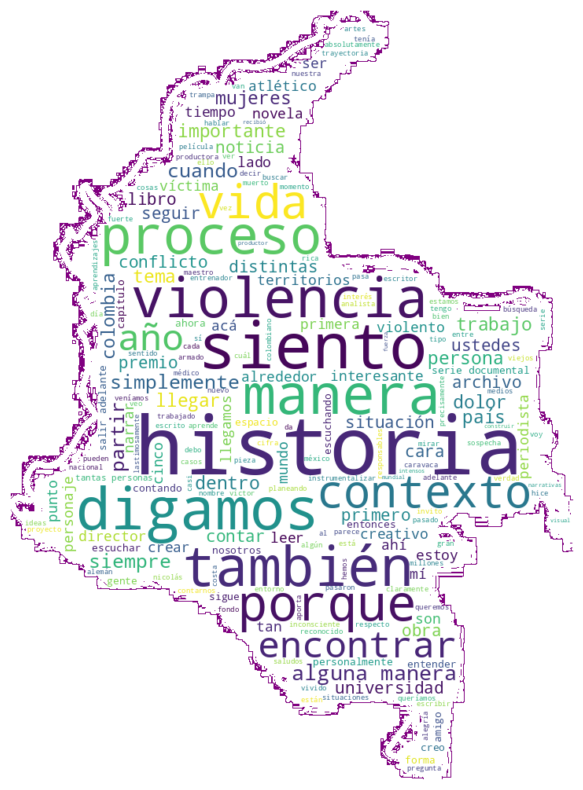

In [ ]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask_image = np.array(Image.open("/content/drive/MyDrive/Ciencia De Datos/Colombia.jpg"))

texto_limpio = " ".join(df_limpio["palabra"])

nube = WordCloud(
    background_color="white",
    mask=mask_image,
    contour_width=1,
    contour_color="purple"
).generate(texto_limpio)

plt.figure(figsize=(10, 10))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()